# Direct Wind Magnet Layout:

## Manual Setup Version:

In [ ]:
%%time
import numpy as np
from iminuit import Minuit
from iminuit.cost import UnbinnedNLL
from scipy.stats import norm
import panel as pn
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
# Sets the floats to round instead of going into scientific notation
np.set_printoptions(suppress=True, formatter={'float_kind':'{:0.6f}'.format})

# =============== Function definitions ===============

# Need to be able to do this for mutiple groups, so different angular bounds at same rad
def plotter(lower, upper, rad, point_num): # Need to find a way to not have them evenly dispersed through the radius, need them side-by-side
    # Iterate through lower and upper angle bounds, with some dphi that determines the spacing
    phi_list = np.linspace(np.deg2rad(lower), np.deg2rad(upper), point_num) # Enter in degrees
    x = rad*np.cos(phi_list)
    y = rad*np.sin(phi_list)
    return x, y

def circ_plot(rad, color='k--'):
    circ = np.linspace(0, 2*np.pi, 500)
    x = rad * np.cos(circ)
    y = rad * np.sin(circ)
    plt.plot(x, y, color, zorder=1)

# The field defined in terms of the harmonics
def B_harm(x, y, x_a, y_a, I):
    # Position of the conductor
    a = np.hypot(x_a, y_a)
    
    # Position of field measurement
    r = np.hypot(x, y)

    # Angle between a and y=0
    phi = np.arctan2(y_a, x_a)
    # Angle between r and y=0
    theta = np.arctan2(y, x)

    # Angle between r and a
    ang = phi - theta

    # Replace r=0 with r=1e-20 to avoid divsion by zero
    r = np.where(r == 0, 1e-10, r)

    # Now we compute the field for both cases, adding up harmonics until the n_max harmonic is calculated and added

    # Case for r < a:
    B_r_in = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(r / a)**(n - 1) * np.sin(n * ang) for n in range(1, n_max+1)], axis=0)
    B_theta_in = (-1)*((mu0 * I) / (2 * np.pi * a)) * np.sum([(r / a)**(n - 1) * np.cos(n * ang) for n in range(1, n_max+1)], axis=0)
    
    # Case for r > a:
    B_r_out = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(a / r)**(n + 1) * np.sin(n * ang) for n in range(0, n_max+1)], axis=0)
    B_theta_out = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(a / r)**(n + 1) * np.cos(n * ang) for n in range(0, n_max+1)], axis=0)

    # Use np.where to select the correct field values to return
    # np.where(cond., x, y) -> If true, takes x; if false, takes y
    B_r = np.where(r > a, B_r_out, B_r_in)
    B_theta = np.where(r > a, B_theta_out, B_theta_in)

    # Convert to cartesian coordinates (notably using the angle theta, not ang)
    B_x = B_r * np.cos(theta) - B_theta * np.sin(theta)
    B_y = B_r * np.sin(theta) + B_theta * np.cos(theta)

    return B_x, B_y

# To calculate the individual harmonic at ref_rad (R0) due to a conductor with current I at position (a, phi)
# Poles go by (n+1), so n=2 -> 3phi -> Sextupole
# 0 = Dipole, 1=Quadrupole, 2=Sextupole, etc.
# For a dipole, even harmonics are not allowed, so here we just look at odd constributions
def Harmonic(R0, a, phi, n, I_wire):
    return (mu0*I_wire/2*np.pi) * (10**4) * ((R0 / a)**n) * np.cos((n + 1) * phi)


# =============== User defined varaiables ===============

# Max n values for field calculation
n_max = 10
# Radius of aperture
aper_rad = 2 
# Min angle from the x-axis for the first block in each layer
min_ang = 20
# Radial spacing
dr = 0.1 
# Thickness of spacing between layers
t = 0.07 
# Reference radius
ref_rad = 1
# Current magnitude
I0 = 500

# Type of magnet: 1=dipole, 2=quadrupole, 3=sextupole
mag_type = 3

# Set it to only show the surface plot for the field strength along the body of the magnet
surf_plot = False

# To set to either show all quadrants or only the first quadrant here:
all_quads = False

# =============== Defined variables ===============
# Vacuum permeability
mu0 = 4 * np.pi * 1e-7 
# Radius of the first layer, based on aperture radius
init_rad = aper_rad + dr 

# Right now, points are distributed uniformly over the angular region, thus, angular spacing between points is not controlled by the user
# spacing = [ [], [], [] ]
# This contains the dphi for each block
# For n blocks we have n+1 spaces to worry about

"""
TO-DO:
Need to make a function that creates a list of angles based on spacing list
Spacing does not have to be the same for each layer
Each spacing value is a delta phi really
Based on the min angle set above
"""
num_of_layers = 3
spacing = []
#spacing = [[] for i in range(n)] # -> makes a list of [ [], [], [], ..., [] ]

# These are just examples for each of the magnet types
if mag_type == 1:
    # Dipole example:
    layers = [ 
                    [ [10], [ (5, 80) ] ], # Layer 1
                    [ [10], [ (5, 80) ] ], # Layer 2
                    [ [10], [ (5, 80) ] ] # Layer 3
             ]
elif mag_type == 2:
    # Quadrupole example:
    layers = [ 
                    [ [5, 5], [ (3, 20), (70, 87) ] ], # Layer 1
                    [ [5, 5], [ (3, 20), (70, 87) ] ], # Layer 2
                    [ [5, 5], [ (3, 20), (70, 87) ] ] # Layer 3
             ]
elif mag_type == 3:
    # Sextupole example:
    layers = [ 
                    [ [3, 6], [ (3, 13), (50, 70)] ], # Layer 1
                    [ [3, 6], [ (3, 13), (50, 70)] ], # Layer 2
                    [ [3, 6], [ (3, 13), (50, 70)] ] # Layer 3
             ]

# =============== Geomerty calculations ===============

# Arrays of the x and y values per layer
x_quad1 = []
y_quad1 = []

# A list of radii to plot based on the layer spacing:
rads = []
# Loops over each layer
for i, layer in enumerate(layers): # Goes from 1-3
    # Radii at which points are plotted, depends only on the layer we are on
    rads.append(init_rad+(2*i*dr) + (i+1)*t) 
    # Loops over the second list in each layer
    for j, ang_list in enumerate(layer[1]):
        # Calulates the x and y values of each conductor for that blocks given angles
        # Accounts for the spacing between the layers, layer[0][j] is the number of conductors
        # x and y are the give an array of coordinates for each conductor in the block
        x, y = plotter(ang_list[0], ang_list[1], init_rad+(2*i*dr) + (i+1)*t, layer[0][j])  
        x_quad1.append(x)
        y_quad1.append(y)


# Concatenation puts them all into just one list
# Concatenated list is still in block order
x_totq1 = np.concatenate(x_quad1)
y_totq1 = np.concatenate(y_quad1)

# Reflect values to each quadrant:
# Q2 
x_totq2 = -1*x_totq1
y_totq2 = y_totq1
# Q3
x_totq3 = -1*x_totq1
y_totq3 = -1*y_totq1
# Q4
x_totq4 = x_totq1
y_totq4 = -1*y_totq1
# Concatenate all these lists to make a total list of x and y values
x_tot = np.concatenate( (x_totq1, x_totq2, x_totq3, x_totq4) )
y_tot = np.concatenate( (y_totq1, y_totq2, y_totq3, y_totq4) )


print(f"Radii of Condutor Layers: {[round(r, 2) for r in rads]}")

# Shows all quadrants or only 1st quadrant based on setting above:
if all_quads:
    # Bounds for all four quadrants:
    bounds =  [ [-3, 3], [-3, 3] ]
elif not all_quads:
    # Bounds for first quadrant only:
    bounds =  [ [0, 3], [0, 3] ]


# =============== Magnetic Field & Harmonic calculations ===============

# Grid setup (for plotting the field)
# The field is always calculated everywhere in this region
x = np.linspace(bounds[0][0], bounds[0][1], 250)
y = np.linspace(bounds[1][0], bounds[1][1], 250)
X, Y = np.meshgrid(x, y)

Bx_total = np.zeros_like(X)
By_total = np.zeros_like(Y)

# Here we caluclate the harmonic components for each n in n_list witin the given ref_rad
n_list = [0, 1, 2, 3, 4]  # dipole, quadrupole, sextupole, octupole, deacpole, etc.

 # From the magtype definition, sets main field to whatever the magnet type is set to
B_main_index = mag_type - 1

# Initializing harmonics array
# Need to intialize to add to the initial zero, otherwise throws an error
harms = np.zeros(len(n_list)) 

# Assigns currents based on magnet type
# Uses cos theta for dipole to change sign
# Uses cos 2theta for quadrupole to change sign
# Uses cos 3theta for sextupole to change sign
# etc.
for xa, ya in zip(x_tot, y_tot):
    phi = np.arctan2(ya, xa)
    a   = np.hypot(xa, ya)
    # Check the sign of cosine to determine the sign of the current
    if np.cos(mag_type*phi) >= 0:
        I = I0
    else:
        I=-I0

    Bx, By = B_harm(X, Y, xa, ya, I)
    if surf_plot == True:
        pass
    else:
        plt.scatter(xa, ya, c=("red" if I >= 0 else "blue"))

    Bx_total += Bx
    By_total += By

    # Calculates the harmonic contribution due to the current conductor
    for j, n_val in enumerate(n_list):
        harms[j] += Harmonic(ref_rad, a, phi, n_val, I)  # Sign of current matters
    
# Total B-field magnitudes are computed
B_mag = np.hypot(Bx_total, By_total)

print("Harmonics [n=0,dipole, n=1,quad, n=2,sext, n=3,oct, n=4,deca]:", harms)
print("Relative to main:", harms / (harms[B_main_index] if harms[B_main_index] != 0 else 1))

# convert to 10^4 units relative to main multipole:
B_main = harms[B_main_index]  # for dipole magnet, n=0 is main
units = (harms / B_main) * 1e4
print("Harmonics in 10^4 units:", units)



# =============== Magnetic Field & Harmonic calculations ===============

if surf_plot == True:
    fig, ax = plt.subplots(figsize=(6,6))
    mask = (X**2 + Y**2 >= aper_rad**2) & (X**2 + Y**2 <= (rads[-1]+dr)**2)
    B_mag_masked = np.where(mask, B_mag, np.nan)
    
    # Create the surface plot (can switch to B_mag_masked)
    pcm = ax.pcolormesh(X, Y, B_mag_masked, shading='auto', cmap='viridis')
    fig.colorbar(pcm, ax=ax, label='Magnetic Field Magnitude (T)')
else:
    # Plots the magnetic field lines
    strm = plt.streamplot(X, Y, Bx_total, By_total, color=B_mag, cmap='viridis', density=3, zorder=0)
    cbar = plt.colorbar(strm.lines, label='Magnetic Field Magnitude (T)')

# Plots circles around \pm dr awway from where the conductors are (offset by t as done above)
for rad in rads:
    circ_plot(rad+dr)
    circ_plot(rad-dr)

# Aperture Radius
circ_plot(aper_rad, color='k:')
# Reference Radius
circ_plot(ref_rad, color='k:')



# ========== USER INPUTS ==========
theta_rad = np.pi/(2*mag_type)  # angle spacing in degrees -> This layout is what we want to copy
r = 5           # length of each line
# =================================

# Plot lines every theta_deg degrees
for i in range(int(2*np.pi / theta_rad)):
    angle = i * theta_rad
    x = [0, r * np.cos(angle)]
    y = [0, r * np.sin(angle)]
    plt.plot(x, y, 'r--', lw=1)

# Draw a reference circle
circ = np.linspace(0, 2*np.pi, 500)
plt.plot(r * np.cos(circ), r * np.sin(circ), 'b:')



plt.xlim(bounds[0][0], bounds[0][1])
plt.ylim(bounds[1][0], bounds[1][1])
plt.xlabel("x")
plt.ylabel("y")
plt.axhline(0, color='black', linewidth=1, zorder=1)
plt.axvline(0, color='black', linewidth=1, zorder=1)
plt.gca().set_aspect('equal')
plt.show()

## Plotting With Proper Spacing:

In this version, we define the spacing from the x-axis for each block. We also show the symmetry lines, depending on the magnet type.

In [ ]:
%%time
import numpy as np
from iminuit import Minuit
from iminuit.cost import UnbinnedNLL
from scipy.stats import norm
import panel as pn
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
# Sets the floats to round instead of going into scientific notation
np.set_printoptions(suppress=True, formatter={'float_kind':'{:0.6f}'.format})

# =============== Function definitions ===============

# Need to be able to do this for mutiple groups, so different angular bounds at same rad

"""
Spacing list is really just a list of angles like before
Spacing (in its current form of 11/5/25) is a list of minor anlges that blocks start at, but this works
"""

# Converts the defined mm value for point radius to s value to be plotted
def mm_to_s(r_mm):
    """Convert marker radius in millimeters to Matplotlib scatter size (s in pt²)."""
    return np.pi * (r_mm / 0.3528)**2

def plotter(spacing, rad, point_num): # Need to find a way to not have them evenly dispersed through the radius, need them side-by-side
    # Iterate through lower and upper angle bounds, with some dphi that determines the spacing

    # Default size of a point
    point_rad = 0.0785 # Default radius of plt.scatter points in data units
    delta_phi_block = (point_num*2*point_rad)/(rad)

    lower = np.deg2rad(spacing)
    upper = delta_phi_block + lower

    
    phi_list = np.linspace(lower, upper, point_num) # Enter in degrees ?
    x = rad*np.cos(phi_list)
    y = rad*np.sin(phi_list)
    return x, y

def circ_plot(rad, color='k--'):
    circ = np.linspace(0, 2*np.pi, 500)
    x = rad * np.cos(circ)
    y = rad * np.sin(circ)
    plt.plot(x, y, color, zorder=1)

# The field defined in terms of the harmonics
def B_harm(x, y, x_a, y_a, I):
    # Position of the conductor
    a = np.hypot(x_a, y_a)
    
    # Position of field measurement
    r = np.hypot(x, y)
    # Replace r=0 with r=1e-20 to avoid divsion by zero
    r = np.where(r == 0, 1e-10, r)

    # Angle between a and y=0
    phi = np.arctan2(y_a, x_a)
    # Angle between r and y=0
    theta = np.arctan2(y, x)

    # Angle between r and a
    ang = phi - theta

    # Now we compute the field for both cases, adding up harmonics until the n_max harmonic is calculated and added

    # Case for r < a:
    B_r_in = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(r / a)**(n - 1) * np.sin(n * ang) for n in range(1, n_max+1)], axis=0)
    B_theta_in = (-1)*((mu0 * I) / (2 * np.pi * a)) * np.sum([(r / a)**(n - 1) * np.cos(n * ang) for n in range(1, n_max+1)], axis=0)
    
    # Case for r > a:
    B_r_out = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(a / r)**(n + 1) * np.sin(n * ang) for n in range(0, n_max+1)], axis=0)
    B_theta_out = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(a / r)**(n + 1) * np.cos(n * ang) for n in range(0, n_max+1)], axis=0)

    # Use np.where to select the correct field values to return
    # np.where(cond., x, y) -> If true, takes x; if false, takes y
    B_r = np.where(r > a, B_r_out, B_r_in)
    B_theta = np.where(r > a, B_theta_out, B_theta_in)

    # Convert to cartesian coordinates (notably using the angle theta, not ang)
    B_x = B_r * np.cos(theta) - B_theta * np.sin(theta)
    B_y = B_r * np.sin(theta) + B_theta * np.cos(theta)

    return B_x, B_y

# To calculate the individual harmonic at ref_rad (R0) due to a conductor with current I at position (a, phi)
# Poles go by (n+1), so n=2 -> 3phi -> Sextupole
# 0 = Dipole, 1=Quadrupole, 2=Sextupole, etc.
# For a dipole, even harmonics are not allowed, so here we just look at odd constributions
def Harmonic(R0, a, phi, n, I_wire):
    return (mu0*I_wire/2*np.pi) * (10**4) * ((R0 / a)**n) * np.cos((n + 1) * phi)


# =============== User defined varaiables ===============

# Max n values for field calculation
n_max = 10
# Radius of aperture
aper_rad = 2 
# Min angle from the x-axis for the first block in each layer
min_ang = 20
# Radial spacing
dr = 0.1 
# Thickness of spacing between layers
t = 0.07 
# Reference radius
ref_rad = 1
# Current magnitude
I0 = 500
# Radius of points in mm
r_mm = 1.5
# Radius of points converted to s units
s_size = mm_to_s(r_mm)

# Type of magnet: 1=dipole, 2=quadrupole, 3=sextupole
mag_type = 3

# Set it to only show the surface plot for the field strength along the body of the magnet
surf_plot = False

# To set to either show all quadrants or only the first quadrant here:
all_quads = True

# =============== Defined variables ===============
# Vacuum permeability
mu0 = 4 * np.pi * 1e-7 
# Radius of the first layer, based on aperture radius
init_rad = aper_rad + dr 

# Right now, points are distributed uniformly over the angular region, thus, angular spacing between points is not controlled by the user
# spacing = [ [], [], [] ]
# This contains the dphi for each block
# For n blocks we have n+1 spaces to worry about

"""
TO-DO:
Need to make a function that creates a list of angles based on spacing list
Spacing does not have to be the same for each layer
Each spacing value is a delta phi really
Based on the min angle set above
"""
num_of_layers = 3
spacing = []
#spacing = [[] for i in range(n)] # -> makes a list of [ [], [], [], ..., [] ]

# These are just examples for each of the magnet types

"""
What we really need here is to have the angles automatically calibrated based on the number of conductors, 
so that the conductors just layout so that they are adjacent
What we really want is the ability to vary the spacing

We can just replace the angle tuple with a spacing tuple that contains all the delta phis

The offset for each block can be calculated from the other angles in the list and the number of conductors

DO THIS TEST:
- Add the spaces and the angles the conductors take up, and see if 


Now, spacing works, but it is spacing from x-axis

"""


# Old Dipole layer
"""
    layers = [ 
                    [ [10], [ (5, 80) ] ], # Layer 1
                    [ [10], [ (5, 80) ] ], # Layer 2
                    [ [10], [ (5, 80) ] ] # Layer 3
             ]
"""



# TEST CASES:
if mag_type == 1:
    # Dipole example:
    layers = [ 
        [ [15], [5] ],
        [ [15], [5] ],
        [ [15], [5] ],
        [ [15], [5] ],
        [ [15], [5] ],
        [ [15], [5] ],
        [ [15], [5] ],
        [ [15], [5] ]
             ]


elif mag_type == 2:
    # Quadrupole example:
    layers = [ 
        [ [3,3], [10,70] ], # Layer 1
        [ [3,3], [10,70] ], 
        [ [3,3], [10,70] ], 
        [ [3,3], [10,70] ], 
        [ [3,3], [10,70] ], 
        [ [3,3], [10,70] ], 
        [ [3,3], [10,70] ], 
        [ [3,3], [10,70] ] 
             ]

# Not correct configuration
elif mag_type == 3:
    # Sextupole example:
    layers = [ 
        [ [3, 6], [3,50] ], # Layer 1
        [ [3, 6], [3,50] ],
        [ [3, 6], [3,50] ],
        [ [3, 6], [3,50] ],
        [ [3, 6], [3,50] ]
             ]

""" 
New Layer layout:

layers = [
    [ [3, 3], [space1a, space2a, space3a] ],
    [ [3, 3], [space1b, space2b, space3b] ]
]

layers[layer][0 = cond_nums, 1 = spacing][i]
"""

# =============== Geomerty calculations ===============

# Arrays of the x and y values per layer
x_quad1 = []
y_quad1 = []


"""
    # Loops over the second list in each layer
    for j, ang_list in enumerate(layer[1]):
        # Calulates the x and y values of each conductor for that blocks given angles
        # Accounts for the spacing between the layers, layer[0][j] is the number of conductors
        # x and y are the give an array of coordinates for each conductor in the block
        x, y = plotter(ang_list[0], ang_list[1], init_rad+(2*i*dr) + (i+1)*t, layer[0][j])  
        x_quad1.append(x)
        y_quad1.append(y)
"""

# A list of radii to plot based on the layer spacing:
rads = []
# Loops over each layer
for i, layer in enumerate(layers): # Goes from 1-3
    # Radii at which points are plotted, depends only on the layer we are on
    rads.append(init_rad+(2*i*dr) + (i+1)*t) 
    # Loops over the second list in each layer
    # Iterates over each spacing value
    for j, space in enumerate(layer[1]):
        # Calulates the x and y values of each conductor for that blocks given angles
        # Accounts for the spacing between the layers
        # x and y are the give an array of coordinates for each conductor in the block
        # layers[i][0][j] is the number of conductors for the current layer, and it loops through this
        # list and it plots for the specified number
        x, y = plotter(space, init_rad+(2*i*dr) + (i+1)*t, layers[i][0][j])  
        x_quad1.append(x)
        y_quad1.append(y)
        

# Concatenation puts them all into just one list
# Concatenated list is still in block order
x_totq1 = np.concatenate(x_quad1)
y_totq1 = np.concatenate(y_quad1)

# Reflect values to each quadrant:
# Q2 
x_totq2 = -1*x_totq1
y_totq2 = y_totq1
# Q3
x_totq3 = -1*x_totq1
y_totq3 = -1*y_totq1
# Q4
x_totq4 = x_totq1
y_totq4 = -1*y_totq1
# Concatenate all these lists to make a total list of x and y values
x_tot = np.concatenate( (x_totq1, x_totq2, x_totq3, x_totq4) )
y_tot = np.concatenate( (y_totq1, y_totq2, y_totq3, y_totq4) )


print(f"Radii of Conductor Layers: {[round(r, 2) for r in rads]}")

# Last value in the rads list:
max_rad = rads[-1]
max_bound = max_rad + 0.5
# Shows all quadrants or only 1st quadrant based on setting above:
if all_quads:
    # Bounds for all four quadrants:
    bounds =  [ [(-1*max_bound), max_bound], [(-1*max_bound), max_bound] ]
elif not all_quads:
    # Bounds for first quadrant only:
    bounds =  [ [0, max_bound], [0, max_bound] ]


# =============== Magnetic Field & Harmonic calculations ===============

# Grid setup (for plotting the field)
# The field is always calculated everywhere in this region
x = np.linspace(bounds[0][0], bounds[0][1], 250)
y = np.linspace(bounds[1][0], bounds[1][1], 250)
X, Y = np.meshgrid(x, y)

Bx_total = np.zeros_like(X)
By_total = np.zeros_like(Y)

# Here we caluclate the harmonic components for each n in n_list witin the given ref_rad
n_list = [0, 1, 2, 3, 4]  # dipole, quadrupole, sextupole, octupole, deacpole, etc.

 # From the magtype definition, sets main field to whatever the magnet type is set to
B_main_index = mag_type - 1

# Initializing harmonics array
# Need to intialize to add to the initial zero, otherwise throws an error
harms = np.zeros(len(n_list)) 

# Assigns currents based on magnet type
# Uses cos theta for dipole to change sign
# Uses cos 2theta for quadrupole to change sign
# Uses cos 3theta for sextupole to change sign
# etc.
for xa, ya in zip(x_tot, y_tot):
    phi = np.arctan2(ya, xa)
    a   = np.hypot(xa, ya)
    # Check the sign of cosine to determine the sign of the current
    if np.cos(mag_type*phi) >= 0:
        I = I0
    else:
        I=-I0

    Bx, By = B_harm(X, Y, xa, ya, I)
    if surf_plot == True:
        pass
    else:
        #plt.scatter(xa, ya, c=("red" if I >= 0 else "blue"), s=s_size)
        plt.scatter(xa, ya, c=("red" if I >= 0 else "blue"))

    Bx_total += Bx
    By_total += By

    # Calculates the harmonic contribution due to the current conductor
    for j, n_val in enumerate(n_list):
        harms[j] += Harmonic(ref_rad, a, phi, n_val, I)  # Sign of current matters
    
# Total B-field magnitudes are computed
B_mag = np.hypot(Bx_total, By_total)

# These index values are shifted from the Python index values which start at i=0
print("Harmonics [n=1,dipole, n=2,quad, n=3,sext, n=4,oct, n=5,deca]:", harms)
print("Relative to main:", harms / (harms[B_main_index] if harms[B_main_index] != 0 else 1))

# convert to 10^4 units relative to main multipole:
B_main = harms[B_main_index]  # for dipole magnet, n=0 is main
units = (harms / B_main) * 1e4
print("Harmonics in 10^4 units:", units)



# =============== Magnetic Field & Harmonic calculations ===============

if surf_plot == True:
    fig, ax = plt.subplots(figsize=(6,6))
    mask = (X**2 + Y**2 >= aper_rad**2) & (X**2 + Y**2 <= (rads[-1]+dr)**2)
    B_mag_masked = np.where(mask, B_mag, np.nan)
    
    # Create the surface plot (can switch to B_mag_masked)
    pcm = ax.pcolormesh(X, Y, B_mag_masked, shading='auto', cmap='viridis')
    fig.colorbar(pcm, ax=ax, label='Magnetic Field Magnitude (T)')
else:
    # Plots the magnetic field lines
    strm = plt.streamplot(X, Y, Bx_total, By_total, color=B_mag, cmap='viridis', density=3, zorder=0)
    cbar = plt.colorbar(strm.lines, label='Magnetic Field Magnitude (T)')

# Plots circles around \pm dr awway from where the conductors are (offset by t as done above)
for rad in rads:
    circ_plot(rad+dr)
    circ_plot(rad-dr)

# Aperture Radius
circ_plot(aper_rad, color='k:')
# Reference Radius
circ_plot(ref_rad, color='k:')



theta_rad = np.pi/(2*mag_type)*2  # angle spacing in degrees -> This layout is what we want to copy
r = 5           # length of each line

# Plot lines every theta_deg degrees
for i in range(int(2*np.pi / theta_rad)):
    angle = i * theta_rad
    x = [0, r * np.cos(angle)]
    y = [0, r * np.sin(angle)]
    plt.plot(x, y, 'r--', lw=1)

# Draw a reference circle
circ = np.linspace(0, 2*np.pi, 500)
plt.plot(ref_rad * np.cos(circ), ref_rad * np.sin(circ), 'k:')



plt.xlim(bounds[0][0], bounds[0][1])
plt.ylim(bounds[1][0], bounds[1][1])
plt.xlabel("x")
plt.ylabel("y")
plt.axhline(0, color='black', linewidth=1, zorder=1)
plt.axvline(0, color='black', linewidth=1, zorder=1)
plt.gca().set_aspect('equal')
plt.show()

## Angle Mirroring:


Radii of Conductor Layers: ['0.10700', '0.13400', '0.16100']
Layer spacings: [0.026999999999999996, 0.026999999999999996]

Harmonics [n=1,dipole, n=2,quad, n=3,sext, n=4,oct, n=5,deca]: [451.4674135868 -0.0000000000 46.7137846467 -0.0000000000 0.8284355659]
Harmonics Relative to main: [1.0000000000 -0.0000000000 0.1034709998 -0.0000000000 0.0018349842]
Harmonics in 10^4 units: [10000.0000000000 -0.0000000000 1034.7099976844 -0.0000000000
 18.3498418925]

Skew Harmonics [n=1,dipole, n=2,quad, n=3,sext, n=4,oct, n=5,deca]: [-0.0000000000 -0.0000000000 -0.0000000000 -0.0000000000 0.0000000000]
Skew Harmonics Relative to main: [1.0000000000 0.0087719298 0.1710526316 0.1063596491 -0.0019188596]
Skew Harmonics in 10^4 units: [10000.0000000000 87.7192982456 1710.5263157895 1063.5964912281
 -19.1885964912]



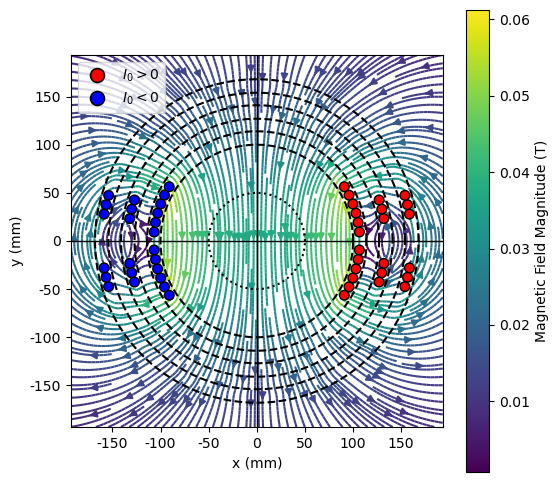

CPU times: total: 9 s
Wall time: 9.02 s


In [15]:
%%time

# =============== Imports ===============
import numpy as np
from iminuit import Minuit
from iminuit.cost import UnbinnedNLL
from scipy.stats import norm
import panel as pn
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D

# Sets the floats to round instead of going into scientific notation
np.set_printoptions(suppress=True, formatter={'float_kind':'{:0.10f}'.format})

# =============== Function definitions ===============

# Applies a rotation matrix to points, rotating them over that angle
def rotate_points(x, y, phi):  
    x_rot = x * np.cos(phi) - y * np.sin(phi)
    y_rot = x * np.sin(phi) + y * np.cos(phi)
    return x_rot, y_rot

# Applies a reflection matrix to points, reflecting them over that angle
def reflect_points(x, y, phi):  
    x_ref = x * np.cos(2 * phi) + y * np.sin(2 * phi)
    y_ref = x * np.sin(2 * phi) - y * np.cos(2 * phi)
    return x_ref, y_ref

# Plots conductors over an angular range, starting at some initial angle from x-axis (need to generalize to inter-block spacing)
def plotter(spacing, rad, point_num):

    # Arc length of the conductor block
    delta_phi_block = (point_num*2*wire_rad)/(rad)

    # The lower bound, given by the spacing of the point
    lower = np.deg2rad(spacing)

    # Angle taken up by a single conductor point
    dphi_point = 2 * np.arcsin(wire_rad / rad)

    # linspace evenly distributes points, which is not what we want
    # So we use np.arange, which distributes at a fixed interval
    # Creates a phi list where points are adjacent to eachother
    phi_list = lower + np.arange(point_num) * dphi_point 

    # Converts points to carteisan so that we can plot them
    x = rad*np.cos(phi_list)
    y = rad*np.sin(phi_list)
    return x, y

# Plots a circle given a radius and a color
def circ_plot(rad, color='k--'):
    circ = np.linspace(0, 2*np.pi, 500)
    x = rad * np.cos(circ)
    y = rad * np.sin(circ)
    plt.plot(x, y, color, zorder=1)

# The field defined in terms of the harmonic contributions
def B_harm(x, y, x_a, y_a, I):
    # Position of the conductor
    a = np.hypot(x_a, y_a)
    
    # Position of field measurement
    r = np.hypot(x, y)
    # Replace r=0 with r=1e-20 to avoid divsion by zero
    r = np.where(r == 0, 1e-10, r)

    # Angle between a and y=0
    phi = np.arctan2(y_a, x_a)
    # Angle between r and y=0
    theta = np.arctan2(y, x)

    # Angle between r and a
    ang = phi - theta

    # Now we compute the field for both cases, adding up harmonics until the n_max harmonic is calculated and added

    # Case for r < a:
    B_r_in = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(r / a)**(n - 1) * np.sin(n * ang) for n in range(1, n_max+1)], axis=0)
    B_theta_in = (-1)*((mu0 * I) / (2 * np.pi * a)) * np.sum([(r / a)**(n - 1) * np.cos(n * ang) for n in range(1, n_max+1)], axis=0)
    
    # Case for r > a:
    B_r_out = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(a / r)**(n + 1) * np.sin(n * ang) for n in range(0, n_max+1)], axis=0)
    B_theta_out = ((mu0 * I) / (2 * np.pi * a)) * np.sum([(a / r)**(n + 1) * np.cos(n * ang) for n in range(0, n_max+1)], axis=0)

    # Use np.where to select the correct field values to return
    # np.where(cond., x, y) -> If true, takes x; if false, takes y
    B_r = np.where(r > a, B_r_out, B_r_in)
    B_theta = np.where(r > a, B_theta_out, B_theta_in)

    # Convert to cartesian coordinates (notably using the angle theta, not ang)
    B_x = B_r * np.cos(theta) - B_theta * np.sin(theta)
    B_y = B_r * np.sin(theta) + B_theta * np.cos(theta)

    return B_x, B_y

# To calculate the individual harmonic at ref_rad (R0) due to a conductor with current I at position (a, phi)
# Poles go by (n+1), so n=2 -> 3phi -> Sextupole
# 0 = Dipole, 1=Quadrupole, 2=Sextupole, etc.
# For a dipole, even harmonics are not allowed, so here we just look at odd constributions (example)
def Harmonic(R0, a, phi, n, I_wire):
    return (mu0*I_wire/2*np.pi) * (10**4) * ((R0 / a)**n) * np.cos((n + 1) * phi)

# Skew-Harmonic:
def skew_Harmonic(R0, a, phi, n, I_wire):
    return (mu0*I_wire/2*np.pi) * (10**4) * ((R0 / a)**n) * np.sin((n + 1) * phi)

# =============== User defined varaiables ===============

# Permeability (vaccuum)
mu0 = 4 * np.pi * 1e-7 
# Max n values for field calculation
n_max = 10
# Radius of aperture
aper_rad = 0.1 
# Thickness of spacing between layers
t = 0.02 
#t = 0.05
# Reference radius
ref_rad = 0.05
# Current magnitude
I0 = 500
# Wire radius in m
wire_rad = 0.005
# Radial spacing
# (0.002 added just to make things more clear on picture)
# Points plot at their center, which is why we need dr to show the physical reality
# Needs to be at least wire_rad
dr = wire_rad+0.002 # = 7 mm
# Type of magnet: 1=dipole, 2=quadrupole, 3=sextupole, etc.
mag_type = 1

# Radius of the first layer, based on aperture radius
# Radius at which first layer of conductors lie, hence the plus dr
#init_rad = aper_rad + dr
#init_rad = aper_rad

# =============== Plot settings ===============

# Set it to only show the surface plot for the field strength along the body of the magnet
surf_plot = False
# To set to either show all quadrants or only the first quadrant here:
all_quads = True

# =============== Layer definition ===============

"""
TO-DO:
- Make spacing be between blocks for blocks that are not the first one
- Remove inner wall spacing
- Install checks to make sure conductor blocks are not overlapping and that they are below the symmetry line
- Create a user interface for inputting configuration info
- Find way to optimize spacing
"""

layers = [
    [ [6], [5] ],
    [ [3], [10] ],
    [ [3], [10] ]
]

# =============== Geomerty calculations ===============

# Arrays of the x and y values per layer in quadrant 1
x_quad1 = []
y_quad1 = []

# A list of radii to plot based on the layer spacing:
rads = []
#rads = [aper_rad + dr + i*(dr + t) for i in range(len(layers))]
# Loops over each layer


# A list of radii to plot based on the layer spacing, starting dr away from aperture radius:
rads = [aper_rad + dr + i*(dr + t) for i in range(len(layers))]

x_quad1 = []
y_quad1 = []

for i, layer in enumerate(layers):
    for j, space in enumerate(layer[1]):
        x, y = plotter(space, rads[i], layers[i][0][j])
        x_quad1.append(x)
        y_quad1.append(y)

print("")
print("Radii of Conductor Layers:", [f"{r:.5f}" for r in rads])
print("Layer spacings:", [rads[i+1] - rads[i] for i in range(len(rads)-1)])
print("")


# Concatenation puts them all into just one list
# Concatenated list is still in block order
x_totq1 = np.concatenate(x_quad1)
y_totq1 = np.concatenate(y_quad1)


# =============== Symmetry mirroring ===============

# Can use a while loop here too, num_sectors is the flag (?)

# Angular spacing between reset lines (reset angle)
reset_angle = np.pi / mag_type

# Offset to mid-axis in each block (symmetry angle)
reflect_angle = np.pi / (2 * mag_type)

# Total number of angular sectors (i.e. reset angles)
# This is the total amount of times we need to iterate
num_sectors = 2 * mag_type

x_blocks = []  
y_blocks = []  

# Loop over the total number of reset sectors
for j in range(num_sectors): 
    # Starting angle
    block_start = j * reset_angle     
    # Defines the mid-axis to reflect over (starting angle for iteration + reflect angle)
    mid_axis = block_start + reflect_angle   

    # Rotate base pattern over by the block start value angle
    xr, yr = rotate_points(x_totq1, y_totq1, block_start)
    x_blocks.append(xr)                                    
    y_blocks.append(yr)                                    

    # Reflect across mid-axis of this block
    xr_ref, yr_ref = reflect_points(xr, yr, mid_axis)      
    x_blocks.append(xr_ref)                                
    y_blocks.append(yr_ref)                                

# Final conductor positions used everywhere below:
x_tot = np.concatenate(x_blocks) 
y_tot = np.concatenate(y_blocks)

# =============== Geometry checks ===============

#print(f"Radii of Conductor Layers: {[round(r, 2) for r in rads]}")

# Last value in the rads list:
max_rad = rads[-1]
max_bound = max_rad*1.2
# Shows all quadrants or only 1st quadrant based on setting above:
if all_quads:
    # Bounds for all four quadrants:
    bounds =  [ [(-1*max_bound), max_bound], [(-1*max_bound), max_bound] ]
elif not all_quads:
    # Bounds for first quadrant only:
    bounds =  [ [0, max_bound], [0, max_bound] ]

# =============== Magnetic Field & Harmonic calculations ===============

# Grid setup (for plotting the field)
# The field is always calculated everywhere in this region
x = np.linspace(bounds[0][0], bounds[0][1], 250)
y = np.linspace(bounds[1][0], bounds[1][1], 250)
X, Y = np.meshgrid(x, y)

Bx_total = np.zeros_like(X)
By_total = np.zeros_like(Y)

# Here we caluclate the harmonic components for each n in n_list witin the given ref_rad
n_list = [0, 1, 2, 3, 4]  # dipole, quadrupole, sextupole, octupole, deacpole, etc.

 # From the magtype definition, sets main field to whatever the magnet type is set to
B_main_index = mag_type - 1

# Initializing harmonics array
# Need to intialize to add to the initial zero, otherwise throws an error
harms = np.zeros(len(n_list)) 
skew_harms = np.zeros(len(n_list)) 

# Assigns currents based on magnet type
# Uses cos theta for dipole to change sign
# Uses cos 2theta for quadrupole to change sign
# Uses cos 3theta for sextupole to change sign
# etc.
#ax = plt.gca()  # use current axes; assume you're already plotting on this
fig, ax = plt.subplots(figsize=(6,6))
for xa, ya in zip(x_tot, y_tot):
    phi = np.arctan2(ya, xa)
    a   = np.hypot(xa, ya)
    # Check the sign of cosine to determine the sign of the current
    if np.cos(mag_type*phi) >= 0:
        I = I0
    else:
        I=-I0

    Bx, By = B_harm(X, Y, xa, ya, I)

    #plt.scatter(xa, ya, c=("red" if I >= 0 else "blue"), s=s_size)
    #plt.scatter(xa, ya, c=("red" if I >= 0 else "blue"))
    color = ("red" if I >= 0 else "blue")
    circ = plt.Circle((xa, ya), wire_rad, edgecolor="black", facecolor=color, linewidth=1, zorder=10)
    ax.add_patch(circ)

    Bx_total += Bx
    By_total += By

    # Calculates the harmonic contribution due to the current conductor
    for j, n_val in enumerate(n_list):
        harms[j] += Harmonic(ref_rad, a, phi, n_val, I)  # Sign of current matters
        skew_harms[j] += skew_Harmonic(ref_rad, a, phi, n_val, I)
        
    
# Total B-field magnitudes are computed
B_mag = np.hypot(Bx_total, By_total)

# convert to 10^4 units relative to main multipole:
B_main = harms[B_main_index]  # for dipole magnet, n=0 is main
units = (harms / B_main) * 1e4

# Skew harmonics normalization:
B_main_skew = skew_harms[B_main_index]
skew_units = (skew_harms / B_main_skew) * 1e4

# These index values are shifted from the Python index values which start at i=0
print("Harmonics [n=1,dipole, n=2,quad, n=3,sext, n=4,oct, n=5,deca]:", harms)
print("Harmonics Relative to main:", harms / (harms[B_main_index] if harms[B_main_index] != 0 else 1))
print("Harmonics in 10^4 units:", units)
print("")
print("Skew Harmonics [n=1,dipole, n=2,quad, n=3,sext, n=4,oct, n=5,deca]:", skew_harms)
print("Skew Harmonics Relative to main:", skew_harms / (skew_harms[B_main_index] if skew_harms[B_main_index] != 0 else 1))
print("Skew Harmonics in 10^4 units:", skew_units)
print("")
"""
    if surf_plot == True:
        pass
    else:
        #plt.scatter(xa, ya, c=("red" if I >= 0 else "blue"), s=s_size)
        #plt.scatter(xa, ya, c=("red" if I >= 0 else "blue"))
        color = ("red" if I >= 0 else "blue")
        circ = plt.Circle((xa, ya), wire_rad, edgecolor="black", facecolor=color, linewidth=1)
        ax.add_patch(circ)
"""

# =============== Magnetic Field & Harmonic calculations ===============

if surf_plot == True:
    #fig, ax = plt.subplots(figsize=(6,6))

    # Code for masking just the ring of conductors:
    #mask = (X**2 + Y**2 >= aper_rad**2) & (X**2 + Y**2 <= (rads[-1]+dr)**2)
    #B_mag_masked = np.where(mask, B_mag, np.nan)
    # Create the surface plot (can switch to B_mag_masked)
    #pcm = ax.pcolormesh(X, Y, B_mag_masked, shading='auto', cmap='viridis')
    
    stream = ax.streamplot(X, Y, Bx_total, By_total, color='white', density=1.2, linewidth=0.8, arrowsize=1)
    # Set the color map resolution
    cmap = plt.colormaps.get_cmap('viridis').resampled(1024)
    pcm = ax.pcolormesh(X, Y, B_mag, shading='auto', cmap=cmap)
    #pcm = ax.pcolormesh(X, Y, B_mag, shading='auto', cmap='viridis')
    fig.colorbar(pcm, ax=ax, label='Magnetic Field Magnitude (T)')
else:
    # Plots the magnetic field lines
    strm = plt.streamplot(X, Y, Bx_total, By_total, color=B_mag, cmap='viridis', density=3, zorder=0)
    cbar = plt.colorbar(strm.lines, label='Magnetic Field Magnitude (T)')

# Plots circles around \pm dr away from where the conductors are (offset by t as done above)
for rad in rads:
    circ_plot(rad+dr)
    circ_plot(rad-dr)
#circ_plot(aper_rad, color='r:')


# Aperture Radius
#circ_plot(aper_rad, color='k:')
# Reference Radius
circ_plot(ref_rad, color='k:')


# Code for plotting symmetry lines
"""
theta_rad = np.pi/(2*mag_type)*2  # angle spacing -> equals pi/mag_type  (same as reset_angle)  # CHANGED (comment only)
r = 5 # length of each line

# Plot lines every theta_rad radians
for i in range(int(2*np.pi / theta_rad)):
    angle = i * theta_rad
    x = [0, r * np.cos(angle)]
    y = [0, r * np.sin(angle)]
    plt.plot(x, y, 'r--', lw=1)
"""

# Draw a reference circle
#circ = np.linspace(0, 2*np.pi, 500)
#plt.plot(ref_rad * np.cos(circ), ref_rad * np.sin(circ), 'k:')



plt.xlim(bounds[0][0], bounds[0][1])
plt.ylim(bounds[1][0], bounds[1][1])
# Format the ticks to show as mm
ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x*1000:g}"))
ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{y*1000:g}"))
plt.xlabel("x (mm)")
plt.ylabel("y (mm)")
plt.axhline(0, color='black', linewidth=1, zorder=1)
plt.axvline(0, color='black', linewidth=1, zorder=1)


legend_elements = [
    Line2D([0], [0], marker='o', color='red', label='$I_0 > 0$', markersize=10, linestyle='', markeredgecolor='black', markeredgewidth=1.2),
    Line2D([0], [0], marker='o', color='blue', label='$I_0 < 0$', markersize=10, linestyle='', markeredgecolor='black', markeredgewidth=1.2)
]
plt.legend(handles=legend_elements, loc='upper left')

#plt.gca().set_aspect('equal')
plt.gca().set_aspect('equal', 'box')
plt.savefig("DirectWindMagnet.pdf")
plt.show()


## GUI Testing:

CPU times: total: 2min 35s
Wall time: 5min 3s


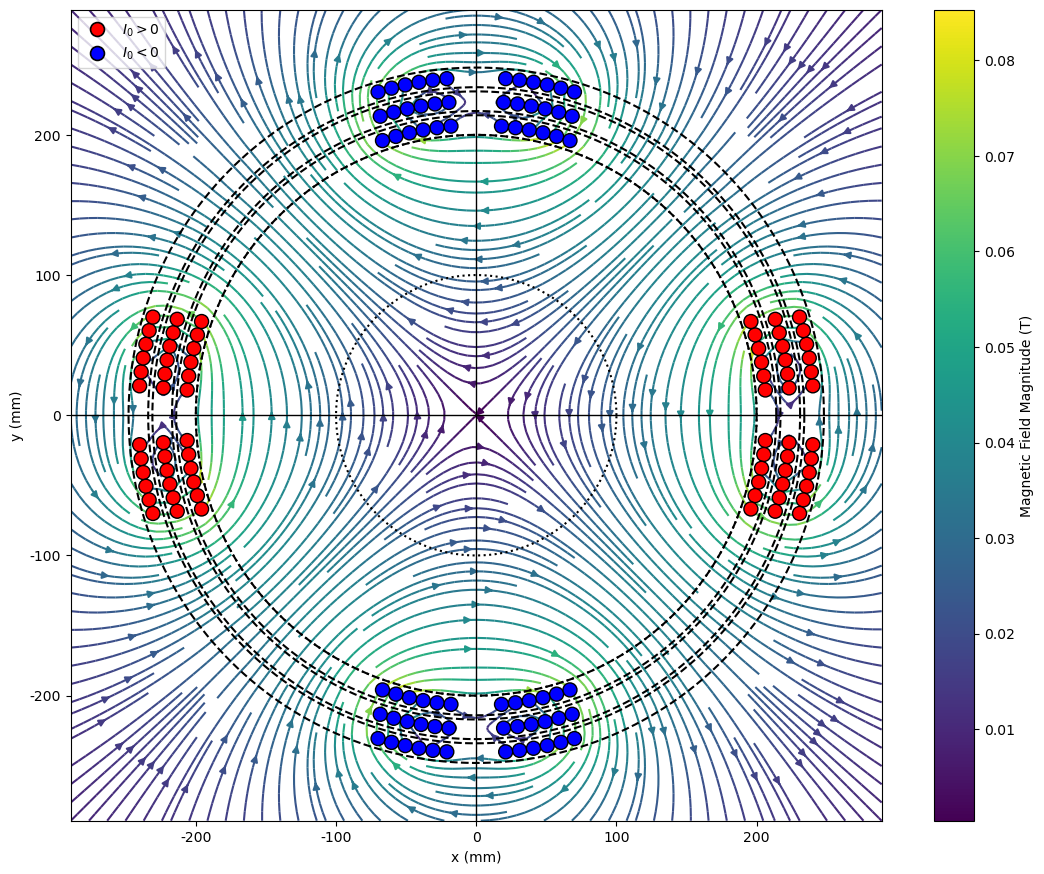

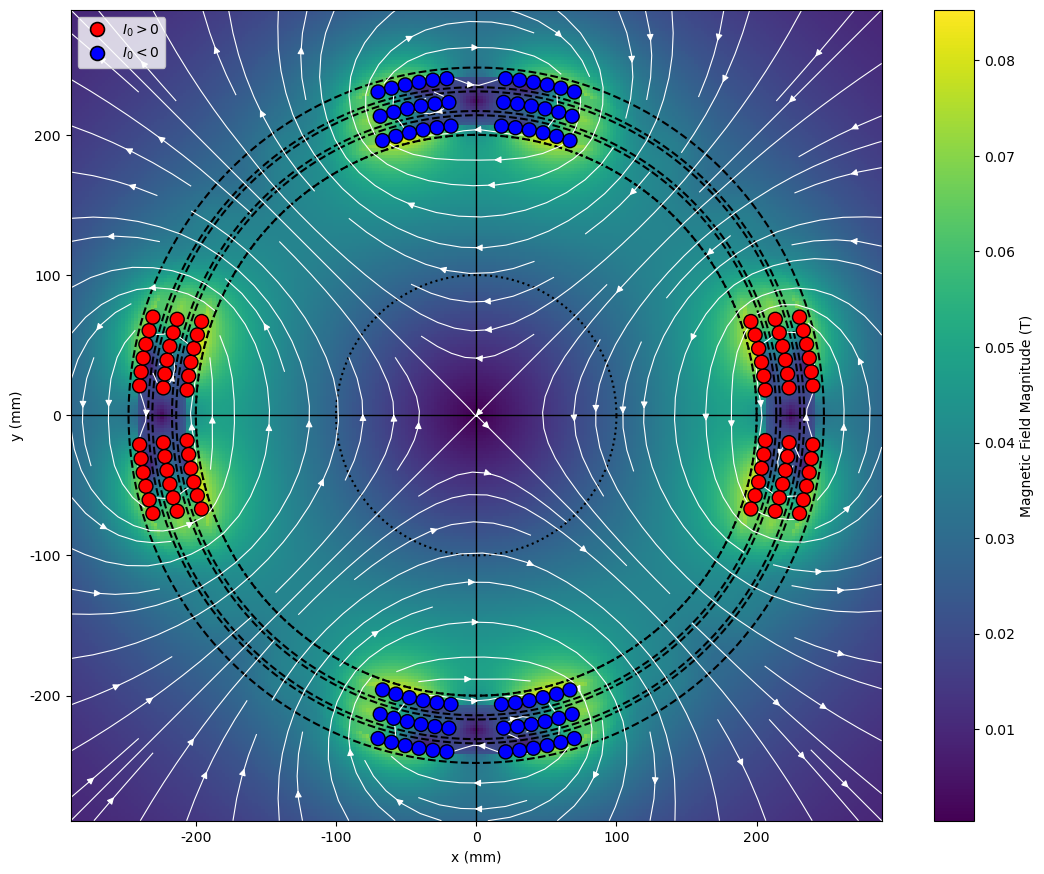

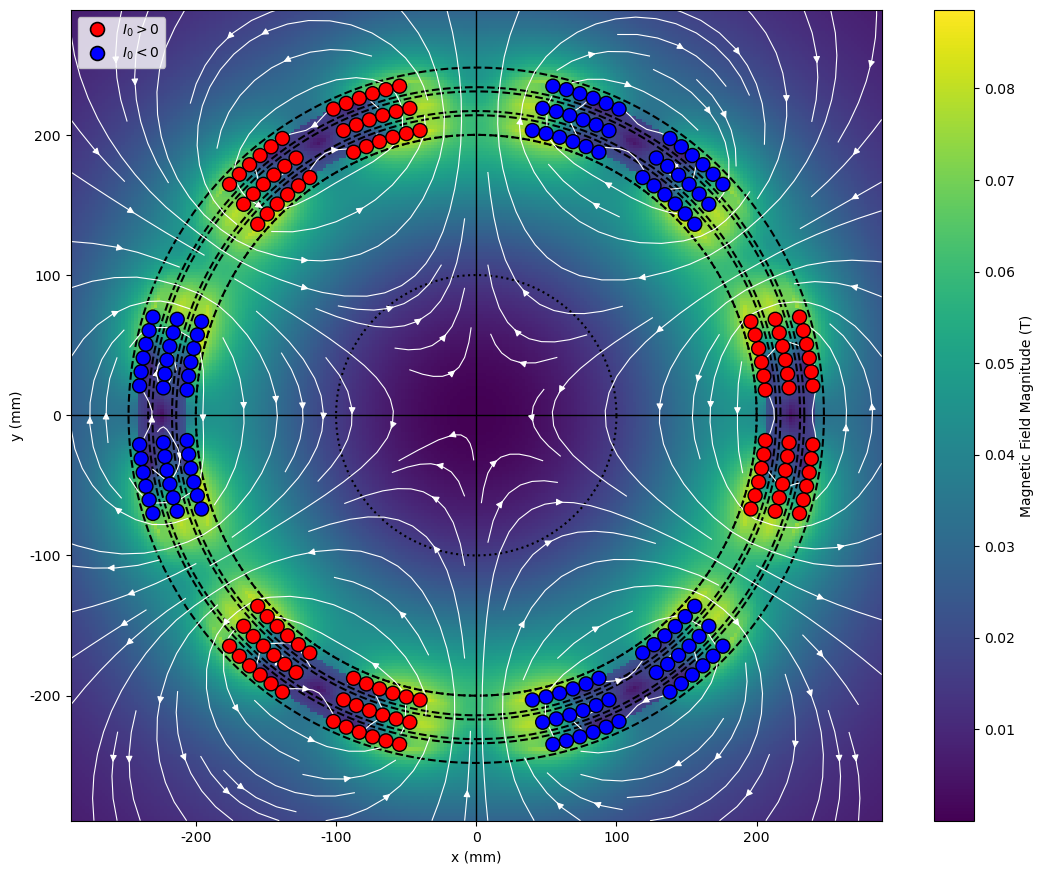

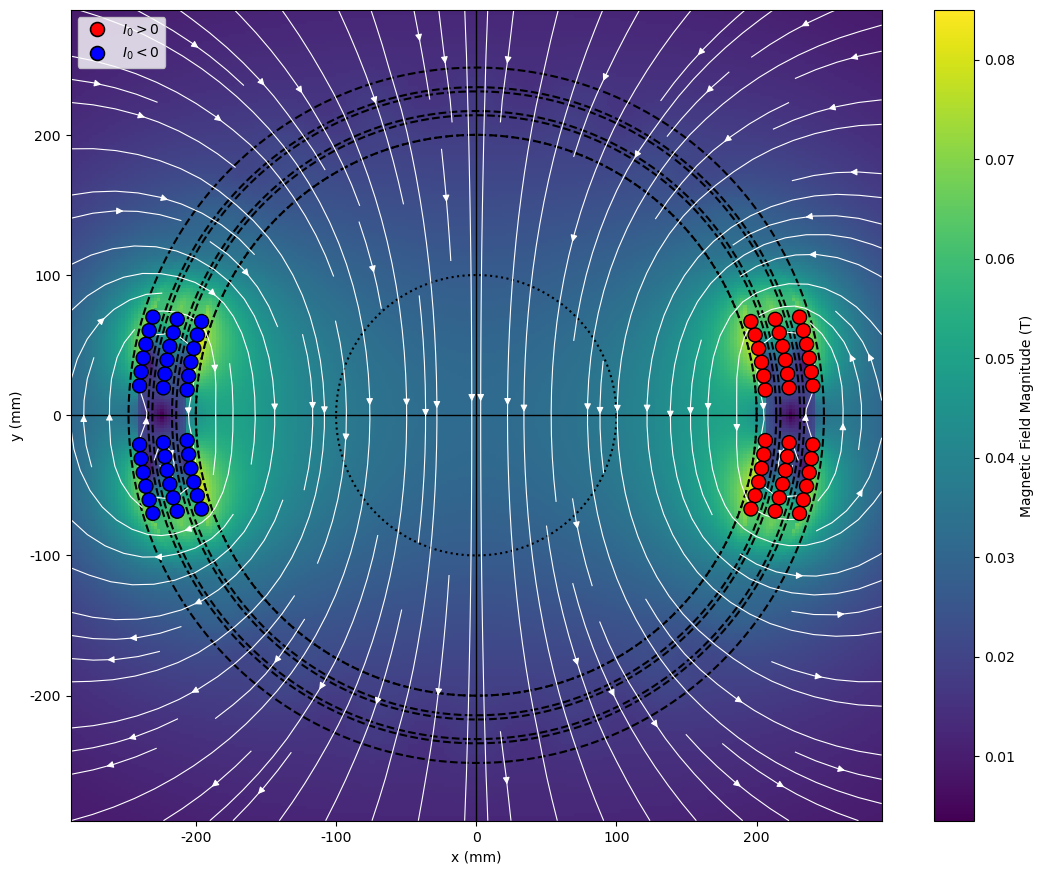

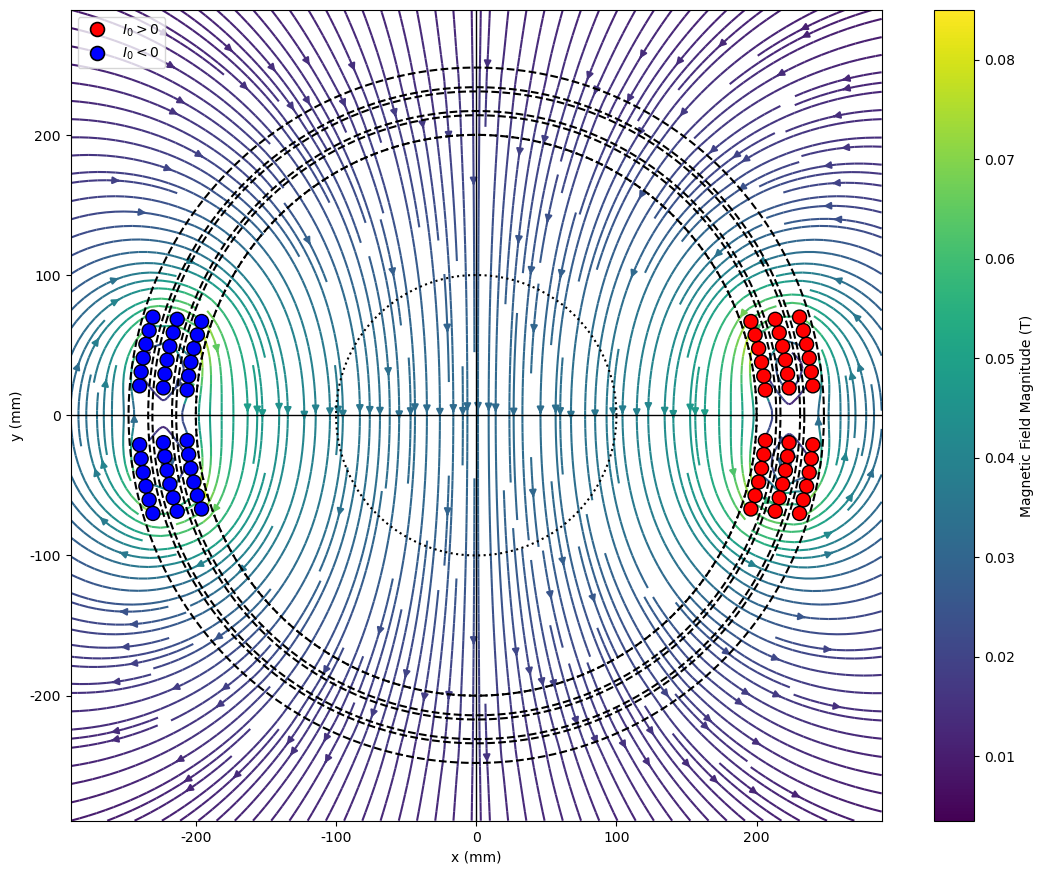

In [27]:
%%time

# =============== Imports ===============
import numpy as np
from iminuit import Minuit
from iminuit.cost import UnbinnedNLL
from scipy.stats import norm
import panel as pn
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
from matplotlib.patches import Circle
from matplotlib.ticker import FuncFormatter
from matplotlib.lines import Line2D
import tkinter as tk
from tkinter import ttk, messagebox
from matplotlib.backends.backend_tkagg import FigureCanvasTkAgg, NavigationToolbar2Tk

# Don't print floats in sci notation by default
np.set_printoptions(suppress=True, formatter={'float_kind': '{:0.10f}'.format})

# =============== Core functions ===============

def rotate_points(x, y, phi):
    """Rotate points by angle phi (radians) around origin."""
    x_rot = x * np.cos(phi) - y * np.sin(phi)
    y_rot = x * np.sin(phi) + y * np.cos(phi)
    return x_rot, y_rot

def reflect_points(x, y, phi):
    """Reflect points across line making angle phi with x-axis."""
    x_ref = x * np.cos(2 * phi) + y * np.sin(2 * phi)
    y_ref = x * np.sin(2 * phi) - y * np.cos(2 * phi)
    return x_ref, y_ref

def plotter(spacing_deg, rad, point_num):
    """
    Compute (x,y) positions of 'point_num' conductors on a circle of radius 'rad',
    starting at angle 'spacing_deg' (deg) and touching each other.
    """
    lower = np.deg2rad(spacing_deg)
    dphi_point = 2 * np.arcsin(wire_rad / rad)
    phi_list = lower + np.arange(point_num) * dphi_point
    x = rad * np.cos(phi_list)
    y = rad * np.sin(phi_list)
    return x, y

def circ_plot(rad, color='k--'):
    """Plot a circle of radius 'rad' on current axes."""
    circ = np.linspace(0, 2*np.pi, 500)
    x = rad * np.cos(circ)
    y = rad * np.sin(circ)
    plt.plot(x, y, color, zorder=1)

def B_harm(x, y, x_a, y_a, I):
    """
    Magnetic field at (x,y) due to single conductor at (x_a,y_a) with current I,
    expanded in harmonics up to n_max.
    """
    a = np.hypot(x_a, y_a)
    r = np.hypot(x, y)
    r = np.where(r == 0, 1e-10, r)  # avoid division by zero

    phi = np.arctan2(y_a, x_a)
    theta = np.arctan2(y, x)
    ang = phi - theta

    # r < a
    B_r_in = ((mu0 * I) / (2 * np.pi * a)) * np.sum(
        [(r / a)**(n - 1) * np.sin(n * ang) for n in range(1, n_max + 1)],
        axis=0
    )
    B_theta_in = -((mu0 * I) / (2 * np.pi * a)) * np.sum(
        [(r / a)**(n - 1) * np.cos(n * ang) for n in range(1, n_max + 1)],
        axis=0
    )

    # r > a
    B_r_out = ((mu0 * I) / (2 * np.pi * a)) * np.sum(
        [(a / r)**(n + 1) * np.sin(n * ang) for n in range(0, n_max + 1)],
        axis=0
    )
    B_theta_out = ((mu0 * I) / (2 * np.pi * a)) * np.sum(
        [(a / r)**(n + 1) * np.cos(n * ang) for n in range(0, n_max + 1)],
        axis=0
    )

    B_r = np.where(r > a, B_r_out, B_r_in)
    B_theta = np.where(r > a, B_theta_out, B_theta_in)

    B_x = B_r * np.cos(theta) - B_theta * np.sin(theta)
    B_y = B_r * np.sin(theta) + B_theta * np.cos(theta)

    return B_x, B_y

def Harmonic(R0, a, phi, n, I_wire):
    """Normal harmonic at R0 for index n (0=dipole,1=quad,...) in 10^4 units."""
    return (mu0 * I_wire / (2 * np.pi)) * 1e4 * ((R0 / a)**n) * np.cos((n + 1) * phi)

def skew_Harmonic(R0, a, phi, n, I_wire):
    """Skew harmonic at R0 for index n (0=dipole,1=quad,...) in 10^4 units."""
    return (mu0 * I_wire / (2 * np.pi)) * 1e4 * ((R0 / a)**n) * np.sin((n + 1) * phi)

# =============== Global parameters (defaults) ===============

mu0 = 4 * np.pi * 1e-7
n_max = 20                # field expansion
aper_rad = 0.2
t = 0.01
ref_rad = 0.1
I0 = 500
wire_rad = 0.005
dr = wire_rad + 0.002
mag_type = 2              # 1=dipole,2=quad,3=sext,...

surf_plot = False
all_quads = True

# default layer structure (just for initial GUI state)
layers = [
    [[6], [5]],
    [[3], [10]],
]

# =====================================================================
# =============== Simulation core (GUI-callable) =======================
# =====================================================================

def direct_wind_simulation(aper_rad_val, t_val, ref_rad_val, I0_val, wire_rad_val, dr_val,
                           mag_type_val, layers_val, surf_plot_val, all_quads_val):
    """
    Run the direct-wind simulation with given parameters and return:
      fig, units, skew_units, n_list, B_main_index
    """
    # Make figure slightly taller than wide to reduce horizontal whitespace
    fig, ax = plt.subplots(figsize=(4.0, 4.8))
    plt.sca(ax)

    # --- Geometry for quadrant 1 (matches your standalone logic) ---
    rads_loc = [aper_rad_val + dr_val + i * (dr_val + t_val)
                for i in range(len(layers_val))]

    x_q1, y_q1 = [], []
    for i, layer in enumerate(layers_val):
        for j, space in enumerate(layer[1]):
            x_loc, y_loc = plotter(space, rads_loc[i], layer[0][j])
            x_q1.append(x_loc)
            y_q1.append(y_loc)

    x_q1 = np.concatenate(x_q1)
    y_q1 = np.concatenate(y_q1)

    # --- Symmetry mirroring ---
    reset_angle = np.pi / mag_type_val
    reflect_angle = np.pi / (2 * mag_type_val)
    num_sectors = 2 * mag_type_val

    x_blocks, y_blocks = [], []
    for j in range(num_sectors):
        block_start = j * reset_angle
        mid_axis = block_start + reflect_angle

        xr, yr = rotate_points(x_q1, y_q1, block_start)
        x_blocks.append(xr)
        y_blocks.append(yr)

        xr_ref, yr_ref = reflect_points(xr, yr, mid_axis)
        x_blocks.append(xr_ref)
        y_blocks.append(yr_ref)

    x_tot = np.concatenate(x_blocks)
    y_tot = np.concatenate(y_blocks)

    # --- Bounds & grid ---
    max_rad = rads_loc[-1]
    max_bound = max_rad * 1.2
    if all_quads_val:
        bounds = [[-max_bound, max_bound], [-max_bound, max_bound]]
    else:
        bounds = [[0, max_bound], [0, max_bound]]

    x = np.linspace(bounds[0][0], bounds[0][1], 250)
    y = np.linspace(bounds[1][0], bounds[1][1], 250)
    X, Y = np.meshgrid(x, y)

    Bx_total = np.zeros_like(X)
    By_total = np.zeros_like(Y)

    n_list = list(range(0, 21))  # 0..20
    B_main_index = mag_type_val - 1
    harms = np.zeros(len(n_list))
    skew_harms = np.zeros(len(n_list))

    # --- Sum contributions from each conductor ---
    for xa, ya in zip(x_tot, y_tot):
        phi = np.arctan2(ya, xa)
        a = np.hypot(xa, ya)

        I_loc = I0_val if np.cos(mag_type_val * phi) >= 0 else -I0_val

        Bx, By = B_harm(X, Y, xa, ya, I_loc)

        # Always draw conductors (both modes), like your reference script
        color = "red" if I_loc >= 0 else "blue"
        circ = Circle(
            (xa, ya), wire_rad_val,
            edgecolor="black", facecolor=color,
            linewidth=1, zorder=10
        )
        ax.add_patch(circ)

        Bx_total += Bx
        By_total += By

        for j_idx, n_val in enumerate(n_list):
            harms[j_idx] += Harmonic(ref_rad_val, a, phi, n_val, I_loc)
            skew_harms[j_idx] += skew_Harmonic(ref_rad_val, a, phi, n_val, I_loc)

    B_mag = np.hypot(Bx_total, By_total)

    # --- Field visualization (EXACT LOGIC FROM YOUR SCRIPT) ---
    if surf_plot_val:
        # White streamlines over high-res viridis surface of B_mag
        stream = ax.streamplot(
            X, Y, Bx_total, By_total,
            color='white', density=1.2, linewidth=0.8, arrowsize=1
        )
        cmap = plt.colormaps.get_cmap('viridis').resampled(1024)
        pcm = ax.pcolormesh(
            X, Y, B_mag, shading='auto', cmap=cmap
        )
        fig.colorbar(pcm, ax=ax, label='Magnetic Field Magnitude (T)')
    else:
        # Streamlines colored by B_mag, with colorbar
        strm = ax.streamplot(
            X, Y, Bx_total, By_total,
            color=B_mag, cmap='viridis',
            density=3, zorder=0
        )
        cbar = plt.colorbar(strm.lines, label='Magnetic Field Magnitude (T)')

    # --- Geometry overlays ---
    for r in rads_loc:
        circ_plot(r + dr_val)
        circ_plot(r - dr_val)

    circ_plot(aper_rad_val, color='k:')
    circ_plot(ref_rad_val, color='k:')

    ax.set_xlim(bounds[0][0], bounds[0][1])
    ax.set_ylim(bounds[1][0], bounds[1][1])
    ax.xaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x*1000:g}"))
    ax.yaxis.set_major_formatter(FuncFormatter(lambda y, pos: f"{y*1000:g}"))
    ax.set_xlabel("x (mm)")
    ax.set_ylabel("y (mm)")
    ax.axhline(0, color='black', linewidth=1, zorder=1)
    ax.axvline(0, color='black', linewidth=1, zorder=1)

    legend_elements = [
        Line2D([0], [0], marker='o', color='red', label='$I_0 > 0$',
               markersize=10, linestyle='', markeredgecolor='black', markeredgewidth=1.2),
        Line2D([0], [0], marker='o', color='blue', label='$I_0 < 0$',
               markersize=10, linestyle='', markeredgecolor='black', markeredgewidth=1.2)
    ]
    ax.legend(handles=legend_elements, loc='upper left')

    ax.set_aspect('equal', 'box')

    # tighten margins; keep plot not too wide inside its figure
    fig.subplots_adjust(left=0.18, right=0.88, top=0.96, bottom=0.20)

    # --- Normalize harmonics (10^4 units) ---
    B_main = harms[B_main_index] if harms[B_main_index] != 0 else 1.0
    units = (harms / B_main) * 1e4

    B_main_skew = skew_harms[B_main_index] if skew_harms[B_main_index] != 0 else 1.0
    skew_units = (skew_harms / B_main_skew) * 1e4

    return fig, units, skew_units, n_list, B_main_index

# =====================================================================
# =============== Tkinter GUI =========================================
# =====================================================================

class DirectWindMagnetGUI(tk.Tk):
    def __init__(self):
        super().__init__()
        self.title("Direct-Wind Magnet Designer")

        self.entries = {}
        self.mag_type_map = {"dipole (1)": 1, "quadrupole (2)": 2,
                             "sextupole (3)": 3, "octupole (4)": 4}

        self.canvas = None
        self.toolbar = None
        self.tree = None

        self.layer_rows = []
        self.layers_frame = None

        self.status_var = tk.StringVar(value="")

        self._create_widgets()

    def _create_widgets(self):
        self.columnconfigure(0, weight=1)
        self.rowconfigure(0, weight=1)

        main_frame = ttk.Frame(self, padding="10")
        main_frame.grid(row=0, column=0, sticky="nsew")

        # Layout (Option B):
        # row 0: col0 = controls, col1 = plot
        # row 1: col0 = harmonics, col1 = (same plot, rowspan=2)
        main_frame.columnconfigure(0, weight=0)
        main_frame.columnconfigure(1, weight=1)
        main_frame.rowconfigure(0, weight=1)
        main_frame.rowconfigure(1, weight=1)

        # Left controls (top-left)
        ctrl_frame = ttk.Frame(main_frame)
        ctrl_frame.grid(row=0, column=0, sticky="nsew", padx=(0, 10))

        # Right plot (spans full height)
        self.plot_frame = ttk.Frame(main_frame)
        self.plot_frame.grid(row=0, column=1, rowspan=2, sticky="nsew")

        # Bottom-left harmonics (same width as controls)
        self.harm_frame = ttk.Frame(main_frame)
        self.harm_frame.grid(row=1, column=0, sticky="nsew", pady=(6, 0))

        # ---- Controls ----
        params = [
            ("Aperture Radius (aper_rad) [m]:", "aper_rad", aper_rad),
            ("Layer Insulation Thickness (t) [m]:", "t", t),
            ("Reference Radius (ref_rad) [m]:", "ref_rad", ref_rad),
            ("Current Magnitude (I0) [A]:", "I0", I0),
            ("Wire Radius (wire_rad) [m]:", "wire_rad", wire_rad),
            ("Radial Spacing dr [m]:", "dr", dr),
        ]

        for i, (label_text, key, default) in enumerate(params):
            ttk.Label(ctrl_frame, text=label_text).grid(row=i, column=0, sticky="w", pady=2)
            entry = ttk.Entry(ctrl_frame, width=16)
            entry.insert(0, str(default))
            entry.grid(row=i, column=1, sticky="we", pady=2)
            self.entries[key] = entry

        # Magnet type dropdown
        row_mt = len(params)
        ttk.Label(ctrl_frame, text="Magnet Type (poles):").grid(row=row_mt, column=0, sticky="w", pady=4)
        self.mag_type_var = tk.StringVar(self)
        for k, v in self.mag_type_map.items():
            if v == mag_type:
                self.mag_type_var.set(k)
                break
        if not self.mag_type_var.get():
            self.mag_type_var.set("quadrupole (2)")
        type_dropdown = ttk.Combobox(
            ctrl_frame, textvariable=self.mag_type_var,
            values=list(self.mag_type_map.keys()),
            width=18, state="readonly"
        )
        type_dropdown.grid(row=row_mt, column=1, sticky="we", pady=4)

        # Layers dynamic area
        row_layers = row_mt + 1
        ttk.Label(ctrl_frame, text="Layers:").grid(row=row_layers, column=0,
                                                   sticky="nw", pady=(6, 2))

        self.layers_frame = ttk.Frame(ctrl_frame)
        self.layers_frame.grid(row=row_layers, column=1, sticky="we", pady=(6, 2))
        self.layers_frame.columnconfigure(0, weight=0)
        self.layers_frame.columnconfigure(1, weight=1)
        self.layers_frame.columnconfigure(2, weight=1)
        self.layers_frame.columnconfigure(3, weight=0)

        ttk.Label(self.layers_frame, text="#").grid(row=0, column=0, padx=2, sticky="w")
        ttk.Label(self.layers_frame, text="N_cond list").grid(row=0, column=1, padx=2, sticky="w")
        ttk.Label(self.layers_frame, text="Start angle list (deg)").grid(row=0, column=2, padx=2, sticky="w")
        ttk.Label(self.layers_frame, text="").grid(row=0, column=3, padx=2, sticky="w")

        try:
            default_n_text = ", ".join(str(v) for v in layers[0][0])
            default_angle_text = ", ".join(str(v) for v in layers[0][1])
        except Exception:
            default_n_text = "6"
            default_angle_text = "5"
        self._add_layer_row(default_n_text, default_angle_text)

        add_layer_row = row_layers + 1
        add_btn = ttk.Button(
            ctrl_frame, text="+ Layer",
            command=lambda: self._add_layer_row(default_n_text, default_angle_text)
        )
        add_btn.grid(row=add_layer_row, column=0, columnspan=2, sticky="w", pady=(4, 6))

        self.surf_var = tk.BooleanVar(value=surf_plot)
        self.quads_var = tk.BooleanVar(value=all_quads)

        ttk.Checkbutton(
            ctrl_frame, text="Surface plot of Field Magnitude",
            variable=self.surf_var
        ).grid(row=add_layer_row+1, column=0, columnspan=2, sticky="w", pady=2)

        ttk.Checkbutton(
            ctrl_frame, text="Show all quadrants",
            variable=self.quads_var
        ).grid(row=add_layer_row+2, column=0, columnspan=2, sticky="w", pady=2)

        run_button = ttk.Button(
            ctrl_frame, text="Run Simulation",
            command=self._run_simulation
        )
        run_button.grid(row=add_layer_row+3, column=0, columnspan=2, pady=(10, 2))

        status_label = ttk.Label(ctrl_frame, textvariable=self.status_var, foreground="blue")
        status_label.grid(row=add_layer_row+4, column=0, columnspan=2, sticky="w", pady=(0, 8))

        ctrl_frame.columnconfigure(1, weight=1)

        # ---- Harmonics table (bottom-left, same width as controls) ----
        self.tree = ttk.Treeview(
            self.harm_frame,
            columns=("contrib", "units", "skew_units"),
            show="headings",
            height=18
        )
        self.tree.heading("contrib", text="Contributions")
        self.tree.heading("units", text="Units (×10⁴)")
        self.tree.heading("skew_units", text="Skew Units (×10⁴)")
        self.tree.column("contrib", width=100, anchor="center")
        self.tree.column("units", width=110, anchor="center")
        self.tree.column("skew_units", width=120, anchor="center")
        self.tree.pack(side="left", fill="both", expand=True, pady=4)

        yscroll = ttk.Scrollbar(self.harm_frame, orient="vertical",
                                command=self.tree.yview)
        self.tree.configure(yscrollcommand=yscroll.set)
        yscroll.pack(side="left", fill="y")

    def _add_layer_row(self, n_text="6", angle_text="5"):
        row_index = len(self.layer_rows) + 1
        lbl = ttk.Label(self.layers_frame, text=f"{row_index}")
        lbl.grid(row=row_index, column=0, padx=2, pady=1, sticky="w")

        n_entry = ttk.Entry(self.layers_frame, width=10)
        n_entry.insert(0, str(n_text))
        n_entry.grid(row=row_index, column=1, padx=2, pady=1, sticky="we")

        ang_entry = ttk.Entry(self.layers_frame, width=14)
        ang_entry.insert(0, str(angle_text))
        ang_entry.grid(row=row_index, column=2, padx=2, pady=1, sticky="we")

        index = len(self.layer_rows)
        remove_btn = ttk.Button(
            self.layers_frame, text="–", width=2,
            command=lambda idx=index: self._remove_layer_row(idx)
        )
        remove_btn.grid(row=row_index, column=3, padx=2, pady=1, sticky="e")

        self.layer_rows.append({
            "label": lbl,
            "n_entry": n_entry,
            "angle_entry": ang_entry,
            "remove_btn": remove_btn
        })

    def _remove_layer_row(self, idx):
        if idx < 0 or idx >= len(self.layer_rows):
            return

        new_data = []
        for i, row in enumerate(self.layer_rows):
            if i == idx:
                continue
            n_text = row["n_entry"].get()
            ang_text = row["angle_entry"].get()
            new_data.append((n_text, ang_text))

        for row in self.layer_rows:
            row["label"].destroy()
            row["n_entry"].destroy()
            row["angle_entry"].destroy()
            row["remove_btn"].destroy()

        self.layer_rows = []
        for n_text, ang_text in new_data:
            self._add_layer_row(n_text, ang_text)

    def _get_inputs(self):
        try:
            aper_rad_val = float(self.entries["aper_rad"].get())
            t_val = float(self.entries["t"].get())
            ref_rad_val = float(self.entries["ref_rad"].get())
            I0_val = float(self.entries["I0"].get())
            wire_rad_val = float(self.entries["wire_rad"].get())
            dr_val = float(self.entries["dr"].get())

            type_str = self.mag_type_var.get()
            if "(" in type_str:
                pole_num = int(type_str.split("(")[1].split(")")[0])
            else:
                pole_num = 2

            if not self.layer_rows:
                raise ValueError("At least one layer is required.")

            layers_val = []
            for row in self.layer_rows:
                raw_n = row["n_entry"].get().strip()
                raw_ang = row["angle_entry"].get().strip()
                if not raw_n or not raw_ang:
                    raise ValueError("Each layer must have N_cond and angle lists.")

                n_strs = [s.strip() for s in raw_n.split(",") if s.strip()]
                ang_strs = [s.strip() for s in raw_ang.split(",") if s.strip()]
                if len(n_strs) != len(ang_strs):
                    raise ValueError("N_cond list and angle list must have same length.")

                n_vals = [int(v) for v in n_strs]
                ang_vals = [float(v) for v in ang_strs]
                if any(n <= 0 for n in n_vals):
                    raise ValueError("Number of conductors must be positive.")

                layers_val.append([n_vals, ang_vals])

            surf_plot_val = bool(self.surf_var.get())
            all_quads_val = bool(self.quads_var.get())

            if aper_rad_val <= 0 or ref_rad_val <= 0 or wire_rad_val <= 0:
                raise ValueError("Radii must be positive.")
            if ref_rad_val >= aper_rad_val:
                raise ValueError("ref_rad must be < aper_rad.")

            return (aper_rad_val, t_val, ref_rad_val, I0_val, wire_rad_val,
                    dr_val, pole_num, layers_val, surf_plot_val, all_quads_val)
        except Exception as e:
            messagebox.showerror("Input Error", f"Invalid input:\n{e}")
            return None

    def _run_simulation(self):
        inputs = self._get_inputs()
        if not inputs:
            return

        self.status_var.set("Running simulation...")
        self.update_idletasks()

        try:
            (aper_rad_val, t_val, ref_rad_val, I0_val, wire_rad_val,
             dr_val, mag_type_val, layers_val, surf_plot_val, all_quads_val) = inputs

            fig, units, skew_units, n_list, main_idx = direct_wind_simulation(
                aper_rad_val, t_val, ref_rad_val, I0_val, wire_rad_val,
                dr_val, mag_type_val, layers_val, surf_plot_val, all_quads_val
            )

            self._update_plot(fig)
            self._update_harmonics(units, skew_units, n_list)
        except Exception as e:
            messagebox.showerror("Simulation Error", f"An error occurred:\n{e}")
        finally:
            self.status_var.set("Ready")

    def _update_plot(self, fig):
        if self.canvas is not None:
            self.canvas.get_tk_widget().destroy()
        if self.toolbar is not None:
            self.toolbar.destroy()

        self.canvas = FigureCanvasTkAgg(fig, master=self.plot_frame)
        canvas_widget = self.canvas.get_tk_widget()
        # Let the plot fill its right-hand column vertically and horizontally
        canvas_widget.pack(side=tk.TOP, fill=tk.BOTH, expand=True)

        self.toolbar = NavigationToolbar2Tk(self.canvas, self.plot_frame)
        self.toolbar.update()
        self.canvas.draw()

    def _update_harmonics(self, units, skew_units, n_list):
        for item in self.tree.get_children():
            self.tree.delete(item)
        for n_val, u_val, us_val in zip(n_list, units, skew_units):
            self.tree.insert(
                "", tk.END,
                values=(n_val, f"{u_val:.4f}", f"{us_val:.4f}")
            )

if __name__ == "__main__":
    app = DirectWindMagnetGUI()
    app.mainloop()
